# 🏎️ Chasing the Checkered Flag — An F1 Exploratory Data Analysis
### Notebook 2 — EDA on 75 years of Formula 1 (1950–2024)

Every insight below is produced by a **live SQL query** against the `f1_analytics` MySQL database
(built in `01_schema.sql`, enriched in Notebook 1), pulled into pandas and visualised with seaborn.
The journey builds toward one question: **what makes a Formula 1 World Champion?**

## 🗺️ Table of Contents
1. 🔌 Setup & schema
2. 📸 Snapshots — the dataset at a glance
3. 🌍 Geography of the sport
4. 👤 Driver demographics
5. 🏎️ Constructors
6. 🏁 Race outcomes & reliability
7. 📈 Trends across eras
8. 🏆 The making of a champion
9. 🔗 Correlation overview
10. ✅ EDA conclusions


## 1. 🔌 Setup & schema

14 tables — dimensions (drivers, constructors, circuits, seasons, status) around the central `races`,
with fact tables (results, qualifying, lap_times, pit_stops, standings) referencing them via 23 foreign
keys.

![ERD](../docs/erd_diagram.png)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style='whitegrid', palette='flare')
plt.rcParams.update({'figure.dpi':110,'axes.titleweight':'bold','figure.autolayout':True})
F1RED = '#e10600'

import os
_u=os.getenv('F1_DB_USER','root'); _p=os.getenv('F1_DB_PASSWORD','root')
_h=os.getenv('F1_DB_HOST','127.0.0.1'); _pt=os.getenv('F1_DB_PORT','3306'); _n=os.getenv('F1_DB_NAME','f1_analytics')
engine = create_engine(f'mysql+pymysql://{_u}:{_p}@{_h}:{_pt}/{_n}?charset=utf8mb4')
def q(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

# reusable champion view: driver who finished P1 in the standings at each season's final round
with engine.begin() as conn:
    conn.execute(text('''CREATE OR REPLACE VIEW v_season_champion AS
        SELECT r.year, ds.driverId
        FROM driver_standings ds JOIN races r ON r.raceId = ds.raceId
        WHERE ds.position = 1
          AND r.round = (SELECT MAX(round) FROM races r2 WHERE r2.year = r.year)'''))
print('Connected. MySQL', q('SELECT VERSION() v').iloc[0,0])


Connected. MySQL 8.0.45


## 2. 📸 Snapshots — the dataset at a glance

,value
races,1125
seasons,75
drivers,861
constructors,212
circuits,77
first_year,1950
last_year,2024


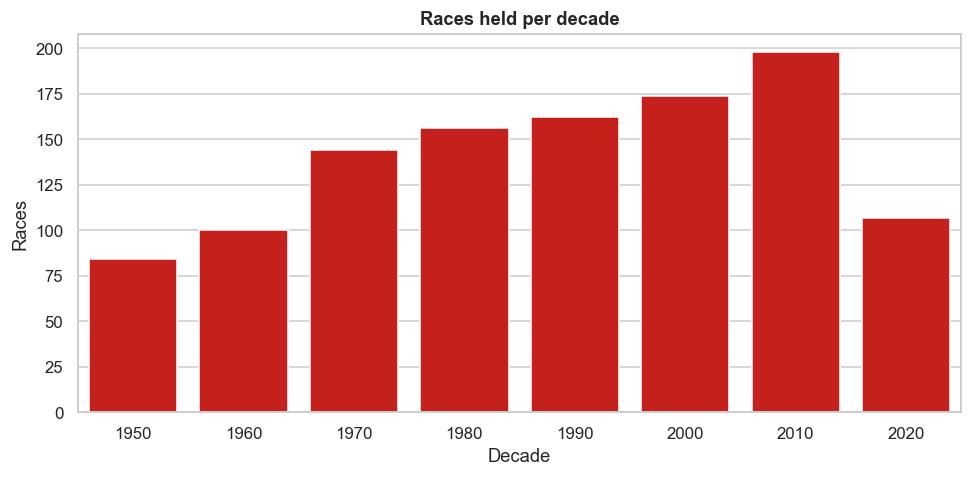

In [2]:
kpi = q('''SELECT
   (SELECT COUNT(*) FROM races)        AS races,
   (SELECT COUNT(DISTINCT year) FROM races) AS seasons,
   (SELECT COUNT(*) FROM drivers)      AS drivers,
   (SELECT COUNT(*) FROM constructors) AS constructors,
   (SELECT COUNT(*) FROM circuits)     AS circuits,
   (SELECT MIN(year) FROM races)       AS first_year,
   (SELECT MAX(year) FROM races)       AS last_year''')
display(kpi.T.rename(columns={0:'value'}))

dec = q('''SELECT FLOOR(year/10)*10 AS decade, COUNT(*) AS races FROM races GROUP BY decade ORDER BY decade''')
fig, ax = plt.subplots(figsize=(9,4.5))
sns.barplot(dec, x='decade', y='races', ax=ax, color=F1RED)
ax.set_title('Races held per decade'); ax.set_xlabel('Decade'); ax.set_ylabel('Races')
plt.show()


*The calendar has exploded — from a handful of races in the 1950s to 200+ per decade in the modern era.*

## 3. 🌍 Geography of the sport

C:\Users\chait\AppData\Local\Temp\ipykernel_27944\1768930563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(geo, y='country', x='circuits', ax=ax, palette='flare')


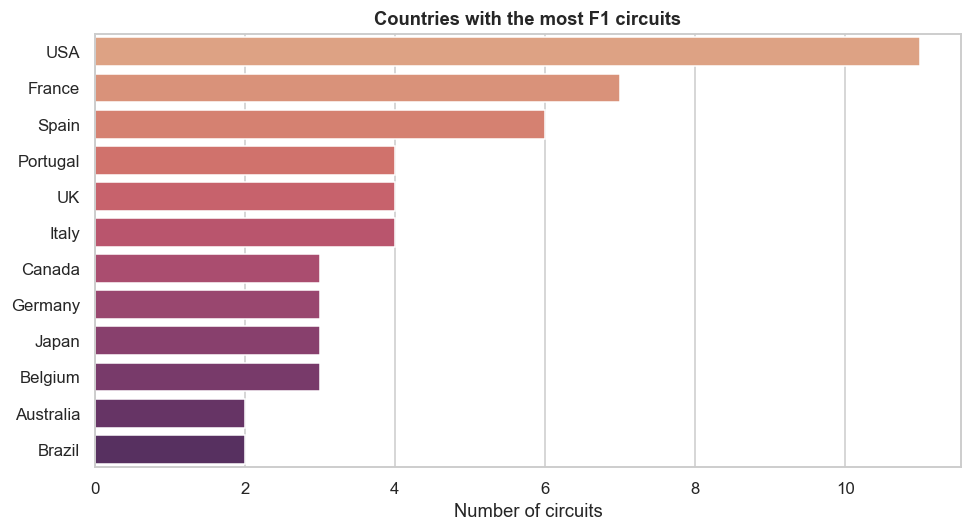

In [3]:
geo = q('''SELECT country, COUNT(*) AS circuits FROM circuits
           GROUP BY country ORDER BY circuits DESC LIMIT 12''')
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(geo, y='country', x='circuits', ax=ax, palette='flare')
ax.set_title('Countries with the most F1 circuits'); ax.set_xlabel('Number of circuits'); ax.set_ylabel('')
plt.show()


## 4. 👤 Driver demographics

C:\Users\chait\AppData\Local\Temp\ipykernel_27944\4031035660.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(nat, y='nationality', x='drivers', ax=ax, palette='rocket')


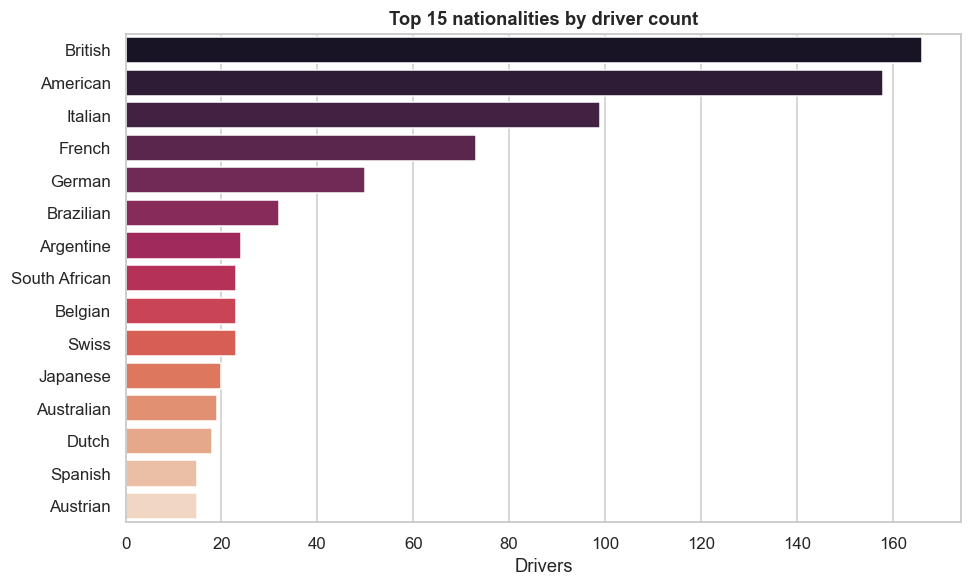

In [4]:
nat = q('''SELECT nationality, COUNT(*) AS drivers FROM drivers
           GROUP BY nationality ORDER BY drivers DESC LIMIT 15''')
fig, ax = plt.subplots(figsize=(9,5.5))
sns.barplot(nat, y='nationality', x='drivers', ax=ax, palette='rocket')
ax.set_title('Top 15 nationalities by driver count'); ax.set_xlabel('Drivers'); ax.set_ylabel('')
plt.show()


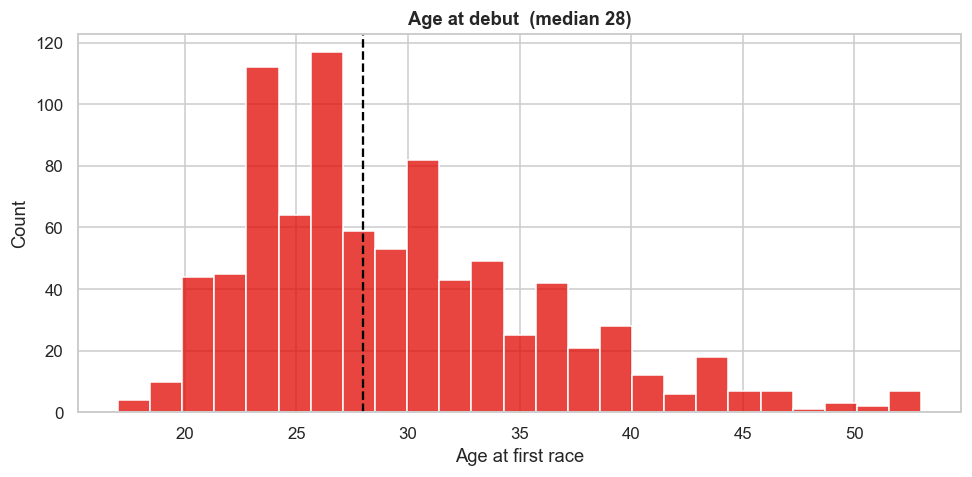

In [5]:
# Age at debut — youngest recorded age per driver = debut age (age rises with each season)
age = q('''SELECT MIN(driver_age) AS debut_age FROM f1_result_features
           WHERE driver_age IS NOT NULL GROUP BY driverId''')
fig, ax = plt.subplots(figsize=(9,4.5))
sns.histplot(age, x='debut_age', bins=25, ax=ax, color=F1RED)
ax.axvline(age['debut_age'].median(), ls='--', color='k')
ax.set_title(f"Age at debut  (median {age['debut_age'].median():.0f})"); ax.set_xlabel('Age at first race')
plt.show()


*Most drivers arrive in their early-to-mid twenties; a long right tail marks the rare late débutants.*

## 5. 🏎️ Constructors

C:\Users\chait\AppData\Local\Temp\ipykernel_27944\334571476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(con, y='name', x='wins', ax=ax, palette='flare')


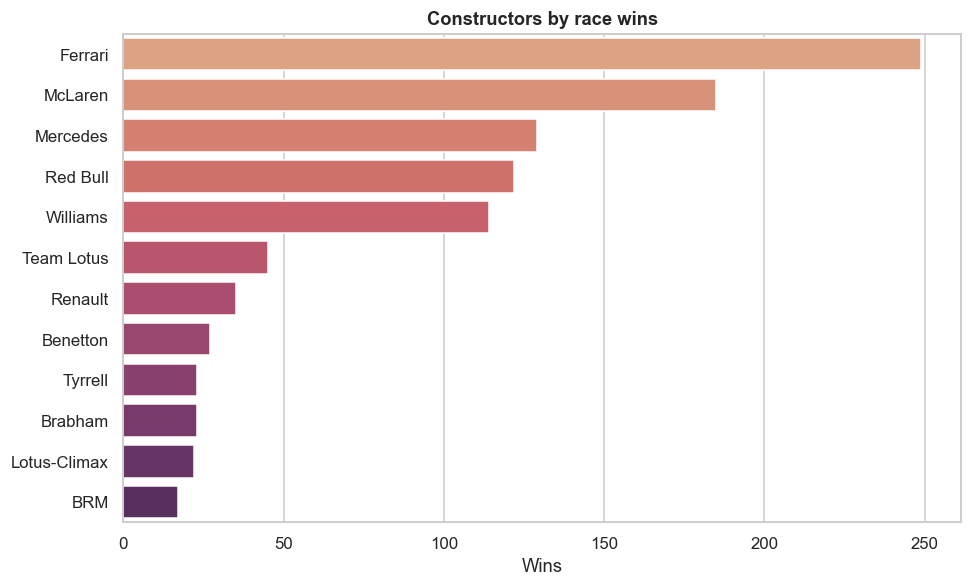

In [6]:
con = q('''SELECT c.name, SUM(f.is_win) AS wins, COUNT(*) AS entries
           FROM f1_result_features f JOIN constructors c ON c.constructorId=f.constructorId
           GROUP BY c.constructorId HAVING wins>0 ORDER BY wins DESC LIMIT 12''')
fig, ax = plt.subplots(figsize=(9,5.5))
sns.barplot(con, y='name', x='wins', ax=ax, palette='flare')
ax.set_title('Constructors by race wins'); ax.set_xlabel('Wins'); ax.set_ylabel('')
plt.show()


## 6. 🏁 Race outcomes & reliability

C:\Users\chait\AppData\Local\Temp\ipykernel_27944\4122306161.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(cat, x='status_category', y='n', ax=ax, palette='rocket')


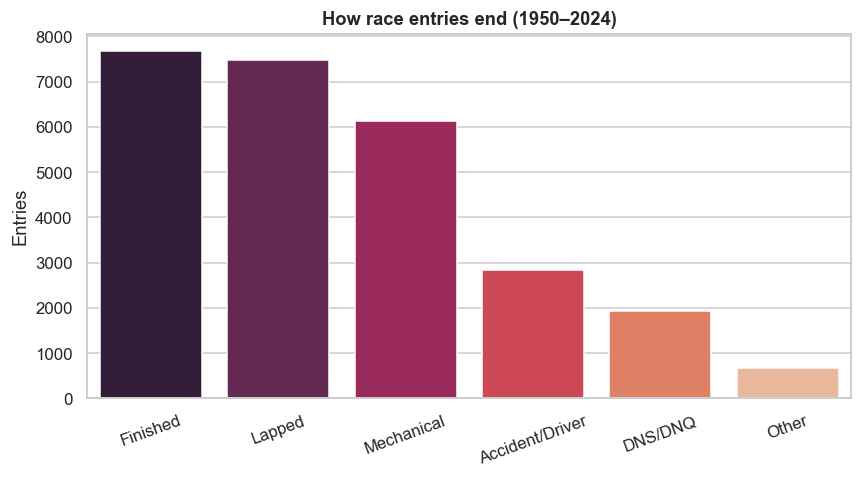

In [7]:
cat = q('''SELECT status_category, COUNT(*) AS n FROM f1_result_features
           GROUP BY status_category ORDER BY n DESC''')
fig, ax = plt.subplots(figsize=(8,4.5))
sns.barplot(cat, x='status_category', y='n', ax=ax, palette='rocket')
ax.set_title('How race entries end (1950–2024)'); ax.set_xlabel(''); ax.set_ylabel('Entries')
plt.xticks(rotation=20); plt.show()


*Only ~29% of entries are classified **Finished**. Mechanical failures and lapped-but-running cars each account for a large share — reliability is a defining feature of the sport's history.*

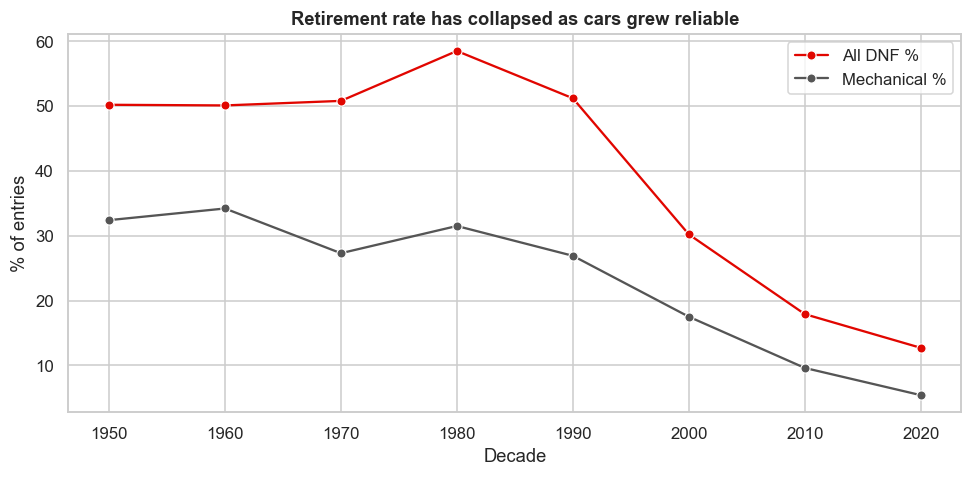

In [8]:
dnf = q('''SELECT decade, ROUND(100*AVG(is_dnf),1) AS dnf_pct,
           ROUND(100*AVG(status_category='Mechanical'),1) AS mech_pct
           FROM f1_result_features GROUP BY decade ORDER BY decade''')
fig, ax = plt.subplots(figsize=(9,4.5))
sns.lineplot(dnf, x='decade', y='dnf_pct', marker='o', ax=ax, label='All DNF %', color=F1RED)
sns.lineplot(dnf, x='decade', y='mech_pct', marker='o', ax=ax, label='Mechanical %', color='#555')
ax.set_title('Retirement rate has collapsed as cars grew reliable'); ax.set_xlabel('Decade'); ax.set_ylabel('% of entries')
plt.show()


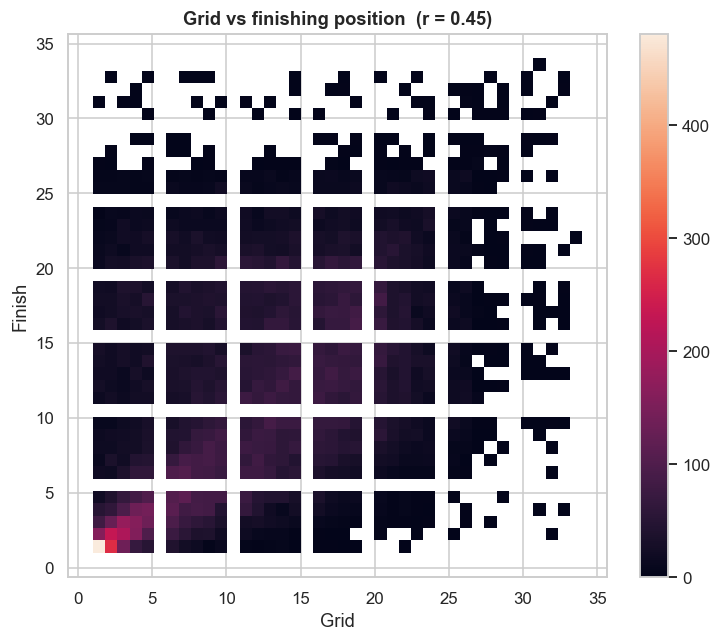

In [9]:
# Grid position vs finishing position
gf = q('''SELECT grid, positionOrder FROM f1_result_features
          WHERE grid>0 AND positionOrder IS NOT NULL''')
r = gf['grid'].corr(gf['positionOrder'])
fig, ax = plt.subplots(figsize=(7,6))
sns.histplot(gf, x='grid', y='positionOrder', bins=40, cmap='rocket', cbar=True, ax=ax)
ax.set_title(f'Grid vs finishing position  (r = {r:.2f})'); ax.set_xlabel('Grid'); ax.set_ylabel('Finish')
plt.show()


*Positive correlation along the diagonal: starting near the front strongly predicts finishing near the front — qualifying matters.*

## 7. 📈 Trends across eras

C:\Users\chait\AppData\Local\Temp\ipykernel_27944\2940621863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ppd, x='decade', y='points', ax=ax, palette='flare', showfliers=False)


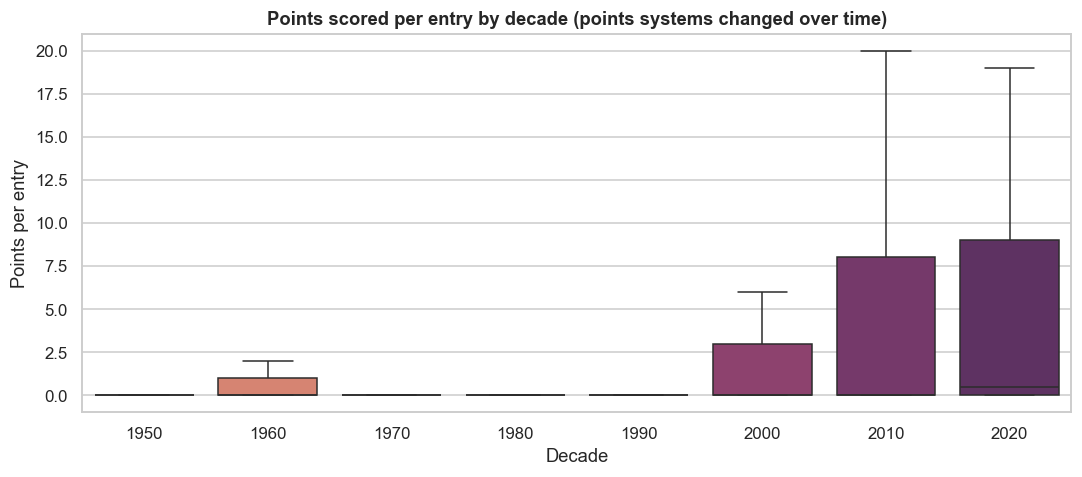

In [10]:
ppd = q('''SELECT decade, points FROM f1_result_features WHERE points IS NOT NULL''')
fig, ax = plt.subplots(figsize=(10,4.5))
sns.boxplot(ppd, x='decade', y='points', ax=ax, palette='flare', showfliers=False)
ax.set_title('Points scored per entry by decade (points systems changed over time)')
ax.set_xlabel('Decade'); ax.set_ylabel('Points per entry')
plt.show()


*Points-per-entry jumps in the 2010s — not because racing changed overnight, but because the **points system** expanded (top-10 scoring, 25 for a win). A reminder to compare eras with rates, not totals.*

## 8. 🏆 The making of a champion

Tying the EDA to the project thesis, using the reusable `v_season_champion` view.

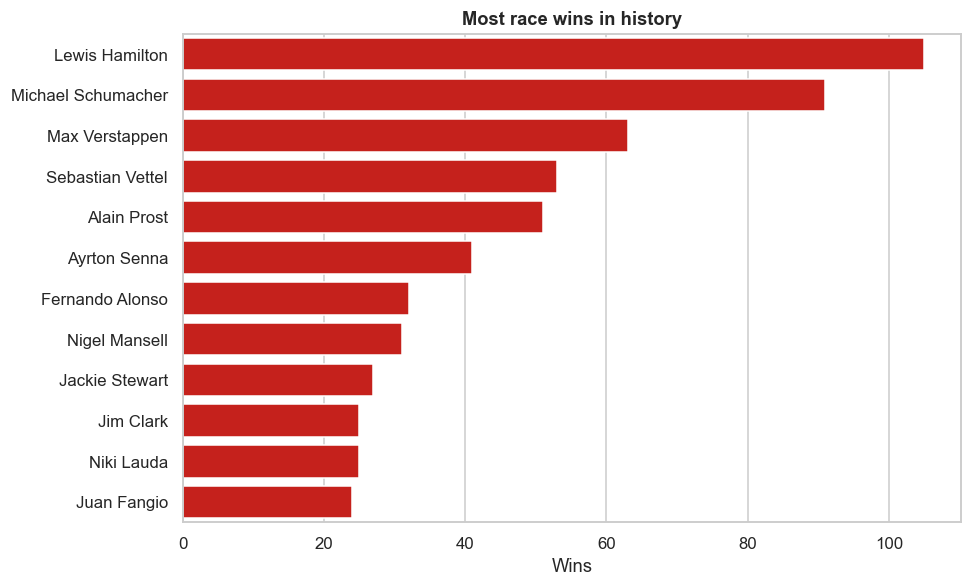

In [11]:
# 8a. Winningest drivers
win = q('''SELECT driver, wins, podiums, poles FROM f1_driver_features ORDER BY wins DESC LIMIT 12''')
fig, ax = plt.subplots(figsize=(9,5.5))
sns.barplot(win, y='driver', x='wins', ax=ax, color=F1RED)
ax.set_title('Most race wins in history'); ax.set_xlabel('Wins'); ax.set_ylabel('')
plt.show()


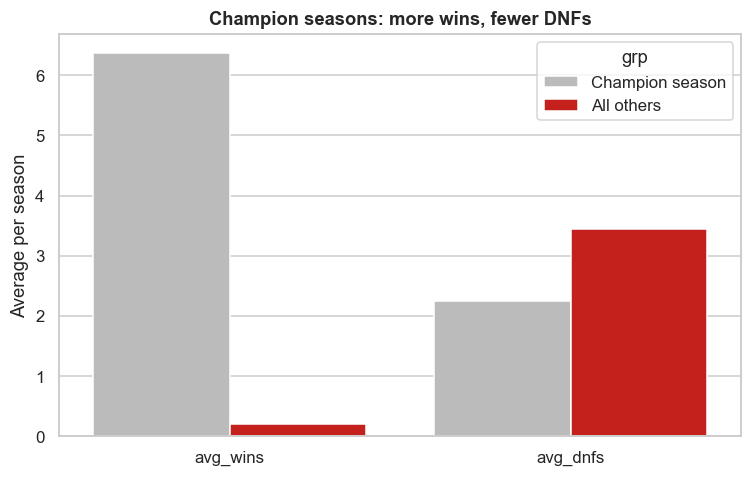

,grp,avg_wins,avg_dnfs
0,Champion season,6.37,2.24
1,All others,0.21,3.44


In [12]:
# 8b. Consistency vs peak — champion seasons vs everyone else
comp = q('''SELECT CASE WHEN sc.driverId IS NOT NULL THEN 'Champion season' ELSE 'All others' END AS grp,
              ROUND(AVG(sd.wins),2) AS avg_wins, ROUND(AVG(sd.dnfs),2) AS avg_dnfs
            FROM f1_season_driver sd
            LEFT JOIN v_season_champion sc ON sc.year=sd.year AND sc.driverId=sd.driverId
            GROUP BY grp''')
m = comp.melt(id_vars='grp', var_name='metric', value_name='avg')
fig, ax = plt.subplots(figsize=(7,4.5))
sns.barplot(m, x='metric', y='avg', hue='grp', ax=ax, palette=['#bbb',F1RED])
ax.set_title('Champion seasons: more wins, fewer DNFs'); ax.set_xlabel(''); ax.set_ylabel('Average per season')
plt.show(); display(comp)


C:\Users\chait\AppData\Local\Temp\ipykernel_27944\2492955794.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(rel, x='grp', y='mech_dnf_pct', ax=ax, palette=[F1RED,'#999'])


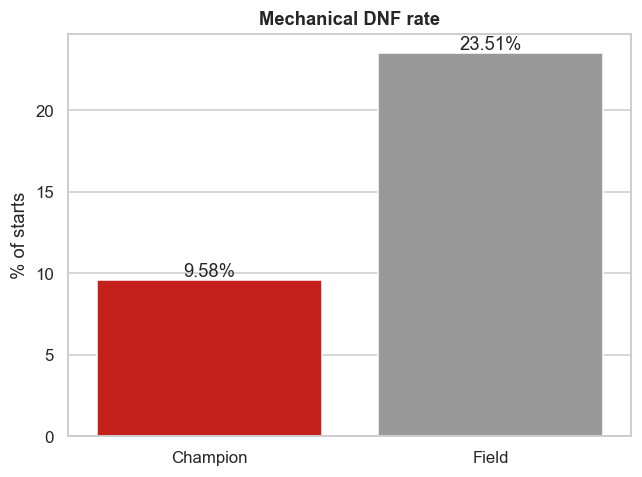

In [13]:
# 8c. Reliability edge — mechanical-DNF rate, champions vs field
rel = q('''SELECT CASE WHEN sc.driverId IS NOT NULL THEN 'Champion' ELSE 'Field' END AS grp,
             ROUND(100*AVG(f.status_category='Mechanical'),2) AS mech_dnf_pct
           FROM f1_result_features f
           LEFT JOIN v_season_champion sc ON sc.year=f.year AND sc.driverId=f.driverId
           GROUP BY grp''')
fig, ax = plt.subplots(figsize=(6,4.5))
sns.barplot(rel, x='grp', y='mech_dnf_pct', ax=ax, palette=[F1RED,'#999'])
for i,v in enumerate(rel['mech_dnf_pct']): ax.text(i,v+0.2,f'{v}%',ha='center')
ax.set_title('Mechanical DNF rate'); ax.set_xlabel(''); ax.set_ylabel('% of starts')
plt.show()


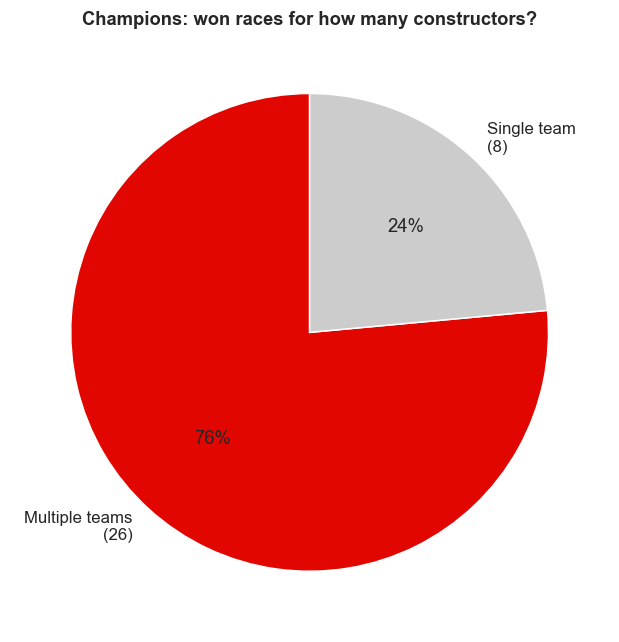

In [14]:
# 8d. Car vs driver — champions who won with multiple constructors
mt = q('''SELECT SUM(t>1) AS multi, SUM(t=1) AS single FROM (
            SELECT sc.driverId, COUNT(DISTINCT CASE WHEN f.is_win=1 THEN f.constructorId END) AS t
            FROM (SELECT DISTINCT driverId FROM v_season_champion) sc
            JOIN f1_result_features f ON f.driverId=sc.driverId
            GROUP BY sc.driverId) x''')
multi, single = int(mt['multi'][0]), int(mt['single'][0])
fig, ax = plt.subplots(figsize=(6,6))
ax.pie([multi,single], labels=[f'Multiple teams\n({multi})', f'Single team\n({single})'],
       autopct='%1.0f%%', colors=[F1RED,'#ccc'], startangle=90, wedgeprops={'edgecolor':'w'})
ax.set_title('Champions: won races for how many constructors?')
plt.show()


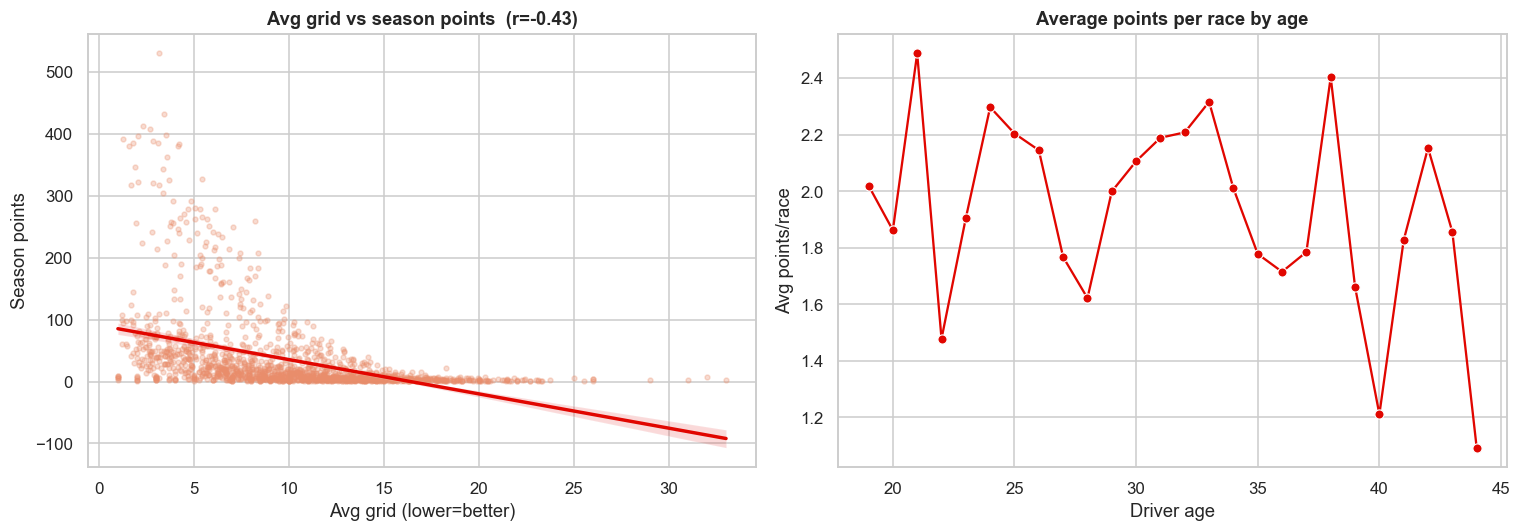

In [15]:
# 8e. Qualifying vs points (driver-seasons) + 8f. Age curve
ds = q('''SELECT avg_grid, points FROM f1_season_driver WHERE avg_grid IS NOT NULL AND points>0''')
age = q('''SELECT driver_age, ROUND(AVG(points),3) AS ppr, COUNT(*) n
           FROM f1_result_features WHERE driver_age IS NOT NULL
           GROUP BY driver_age HAVING n>=100 ORDER BY driver_age''')
fig, axes = plt.subplots(1,2, figsize=(14,5))
r = ds['avg_grid'].corr(ds['points'])
sns.regplot(ds, x='avg_grid', y='points', scatter_kws={'s':10,'alpha':.3}, line_kws={'color':F1RED}, ax=axes[0])
axes[0].set_title(f'Avg grid vs season points  (r={r:.2f})'); axes[0].set_xlabel('Avg grid (lower=better)'); axes[0].set_ylabel('Season points')
sns.lineplot(age, x='driver_age', y='ppr', marker='o', color=F1RED, ax=axes[1])
axes[1].set_title('Average points per race by age'); axes[1].set_xlabel('Driver age'); axes[1].set_ylabel('Avg points/race')
plt.show()


*Qualifying and points correlate moderately negatively (better grid → more points). The age curve is a broad plateau — no rookie penalty, no single sharp peak.*

## 9. 🔗 Correlation overview

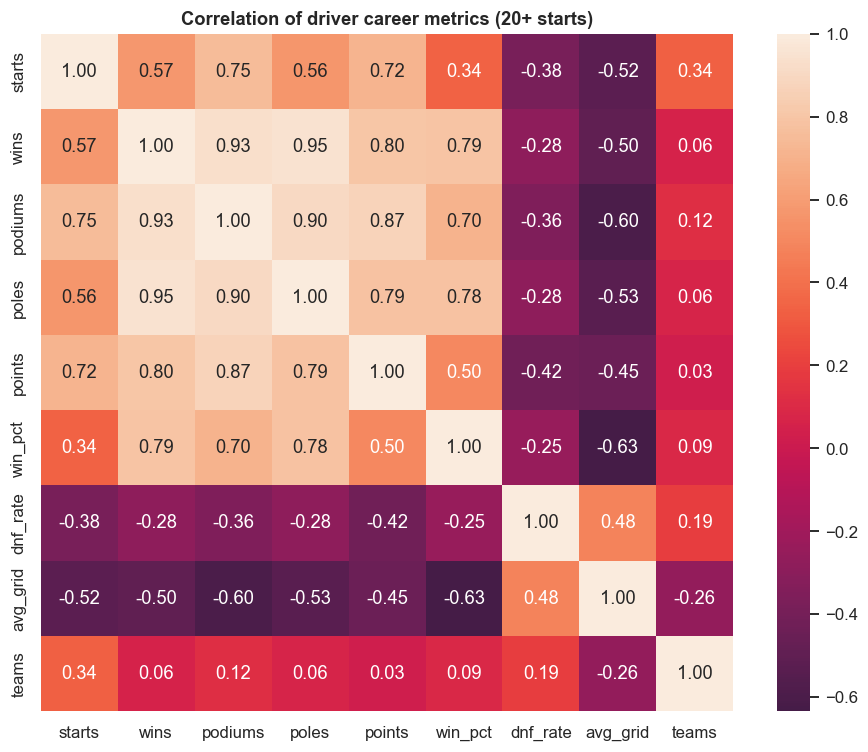

In [16]:
corr_df = q('''SELECT starts, wins, podiums, poles, points, win_pct, dnf_rate, avg_grid, teams
               FROM f1_driver_features WHERE starts>=20''')
fig, ax = plt.subplots(figsize=(8.5,7))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='rocket', center=0, ax=ax)
ax.set_title('Correlation of driver career metrics (20+ starts)')
plt.show()


*`avg_grid` is negatively correlated with wins/points (front-runners win); `dnf_rate` is negatively correlated with success — the reliability story again.*

## 10. ✅ EDA conclusions

- **The sport scaled up**: races per decade grew ~40×; reliability transformed a ~60% retirement era
  into today's sub-15%.
- **Qualifying is real signal**: grid position correlates clearly with finishing and season points.
- **Champions are made by consistency + reliability**, not peak pace alone — champion seasons average
  more wins *and* fewer DNFs, and champions suffer far fewer mechanical failures.
- **Great drivers transcend the car**: most champions won races for more than one constructor.
- **Compare eras carefully**: points-per-entry jumped with points-system changes, not driver quality.

These feed directly into the project thesis in `docs/findings_report.md`.
